In [4]:
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("../..").resolve()

DATA_DIR = PROJECT_ROOT / "results" / "results_ood_vs_random_shuffle" / "hi" / "drd2"
FIG_DIR = DATA_DIR / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

summary = pd.read_csv(DATA_DIR / "protocol_summary_numeric.csv")
summary_display = pd.read_csv(DATA_DIR / "protocol_summary_display.csv")
delta = pd.read_csv(DATA_DIR / "protocol_delta.csv")
folds = pd.read_csv(DATA_DIR / "protocol_per_fold.csv")

summary["experiment_label"] = summary["model"] + " + " + summary["fingerprint"]

summary.head()

,model,model_short,fingerprint,protocol,inner_mean,inner_std,inner_train_mean,inner_train_std,train_mean,train_std,test_mean,test_std,inner_test_gap_mean,inner_test_gap_std,train_test_gap_mean,train_test_gap_std,model_order,fingerprint_order,protocol_order,experiment_label
0,Decision Tree,DT,ECFP4,OOD holdout,0.764178,0.081028,0.898665,0.022810,0.850033,0.050247,0.716400,0.046967,0.047778,0.113842,0.133633,0.080803,0,0,0,Decision Tree + ECFP4
1,Decision Tree,DT,ECFP4,Random shuffle,0.888541,0.038240,0.941363,0.032074,0.928400,0.045711,0.677367,0.068118,0.211174,0.105854,0.251033,0.112735,0,0,1,Decision Tree + ECFP4
2,Decision Tree,DT,MACCS,OOD holdout,0.768390,0.065095,0.881364,0.048533,0.866533,0.092405,0.680200,0.068243,0.088190,0.118060,0.186333,0.136157,0,1,0,Decision Tree + MACCS
3,Decision Tree,DT,MACCS,Random shuffle,0.888069,0.034918,0.952155,0.004306,0.950233,0.004842,0.673933,0.082550,0.214136,0.116424,0.276300,0.085593,0,1,1,Decision Tree + MACCS
4,Logistic Regression,LR,ECFP4,OOD holdout,0.751440,0.099063,0.956816,0.019738,0.944067,0.034693,0.757200,0.099614,-0.005760,0.191766,0.186867,0.098506,1,0,0,Logistic Regression + ECFP4


# Scatter: inner mean vs final OOD test mean

Mean inner validation PR-AUC with the final mean OOD test PR-AUC for each model–fingerprint–protocol combination.

The diagonal line represents perfect agreement between internal validation and final OOD performance. Points above the diagonal indicate optimistic internal validation estimates.

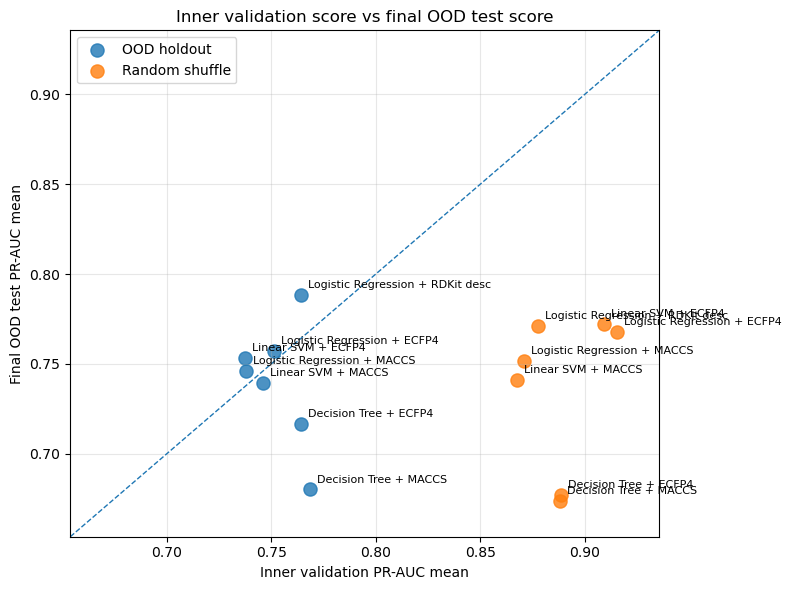

In [6]:

x_col = "inner_mean"
y_col = "test_mean"

fig, ax = plt.subplots(figsize=(8, 6))

for protocol in ["OOD holdout", "Random shuffle"]:
    sub = summary[summary["protocol"] == protocol]

    ax.scatter(
        sub[x_col],
        sub[y_col],
        label=protocol,
        s=90,
        alpha=0.8,
    )

    for _, row in sub.iterrows():
        ax.annotate(
            row["experiment_label"],
            (row[x_col], row[y_col]),
            textcoords="offset points",
            xytext=(5, 5),
            fontsize=8,
        )

min_val = min(summary[x_col].min(), summary[y_col].min()) - 0.02
max_val = max(summary[x_col].max(), summary[y_col].max()) + 0.02

ax.plot(
    [min_val, max_val],
    [min_val, max_val],
    linestyle="--",
    linewidth=1,
)

ax.set_xlabel("Inner validation PR-AUC mean")
ax.set_ylabel("Final OOD test PR-AUC mean")
ax.set_title("Inner validation score vs final OOD test score")
ax.set_xlim(min_val, max_val)
ax.set_ylim(min_val, max_val)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "01_inner_vs_test_scatter.png", dpi=300, bbox_inches="tight")
plt.show()

# Inner-to-test gap by model, fingerprint and protocol

The inner-to-test gap is computed as:


gap = mean inner validation PR-AUC - mean final OOD test PR-AUC


A larger positive gap indicates that the inner validation protocol overestimates the final OOD performance.

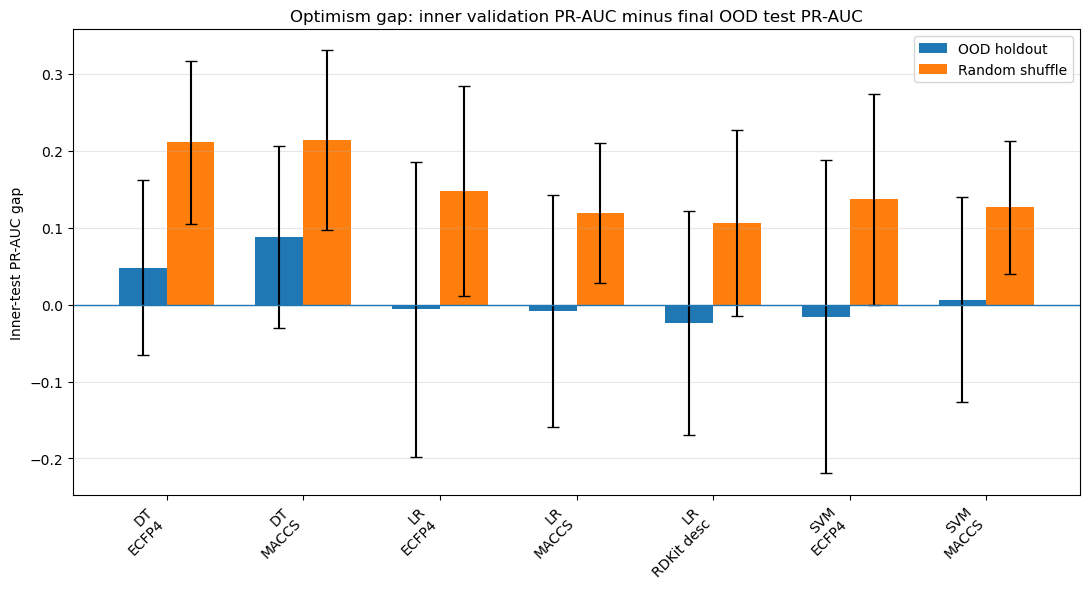

In [9]:
plot_df = summary.copy()

plot_df["experiment_label"] = (
    plot_df["model_short"] + "\n" + plot_df["fingerprint"]
)

plot_df = plot_df.sort_values(
    ["model_order", "fingerprint_order", "protocol_order"]
)

labels = plot_df["experiment_label"].drop_duplicates().tolist()
protocols = plot_df["protocol"].drop_duplicates().tolist()

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

for i, protocol in enumerate(protocols):
    sub = (
        plot_df[plot_df["protocol"] == protocol]
        .set_index("experiment_label")
        .reindex(labels)
        .reset_index()
    )

    offset = (i - (len(protocols) - 1) / 2) * width

    ax.bar(
        x + offset,
        sub["inner_test_gap_mean"],
        width,
        yerr=sub["inner_test_gap_std"],
        capsize=4,
        label=protocol,
    )

ax.axhline(0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Inner-test PR-AUC gap")
ax.set_title("Optimism gap: inner validation PR-AUC minus final OOD test PR-AUC")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "02_inner_test_gap_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

# Final OOD test PR-AUC by protocol

Comparison between the final OOD test PR-AUC across protocols. The error bars represent the standard deviation across the three outer folds.

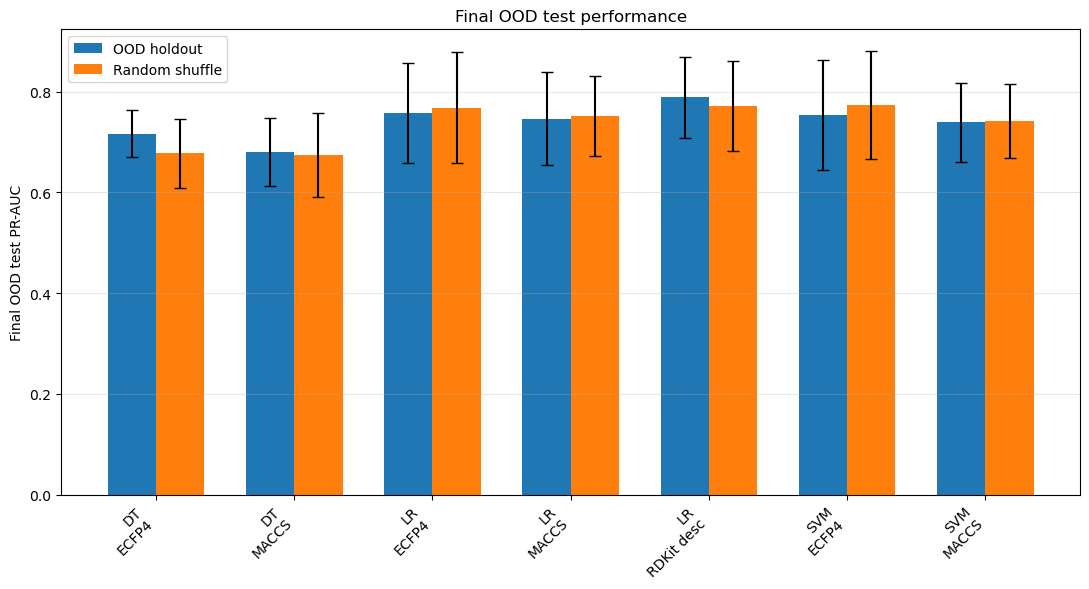

In [10]:
plot_df = summary.copy()

plot_df["experiment_label"] = (
    plot_df["model_short"] + "\n" + plot_df["fingerprint"]
)

plot_df = plot_df.sort_values(
    ["model_order", "fingerprint_order", "protocol_order"]
)

labels = plot_df["experiment_label"].drop_duplicates().tolist()
protocols = plot_df["protocol"].drop_duplicates().tolist()

x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(11, 6))

for i, protocol in enumerate(protocols):
    sub = (
        plot_df[plot_df["protocol"] == protocol]
        .set_index("experiment_label")
        .reindex(labels)
        .reset_index()
    )

    offset = (i - (len(protocols) - 1) / 2) * width

    ax.bar(
        x + offset,
        sub["test_mean"],
        width,
        yerr=sub["test_std"],
        capsize=4,
        label=protocol,
    )

ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Final OOD test PR-AUC")
ax.set_title("Final OOD test performance")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "03_final_test_pr_auc_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

# Fold-wise inner-to-test gap

Inner-to-test gap separately taken for each outer fold.

This is useful because the effect of the validation protocol may not be uniform across folds.

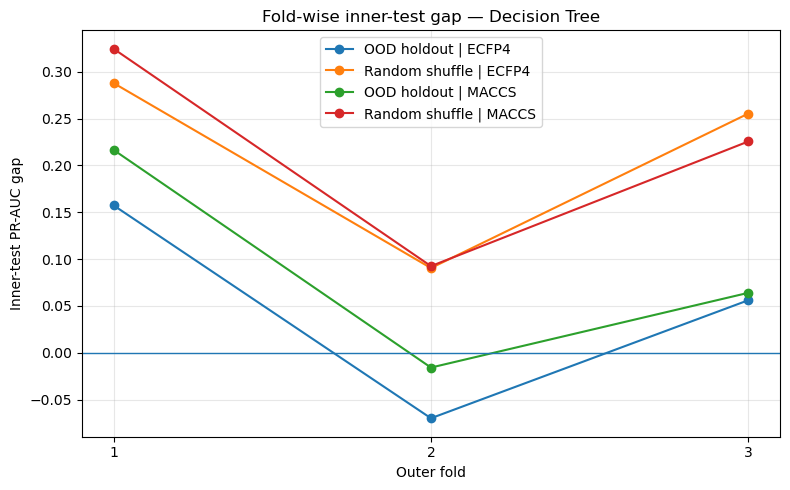

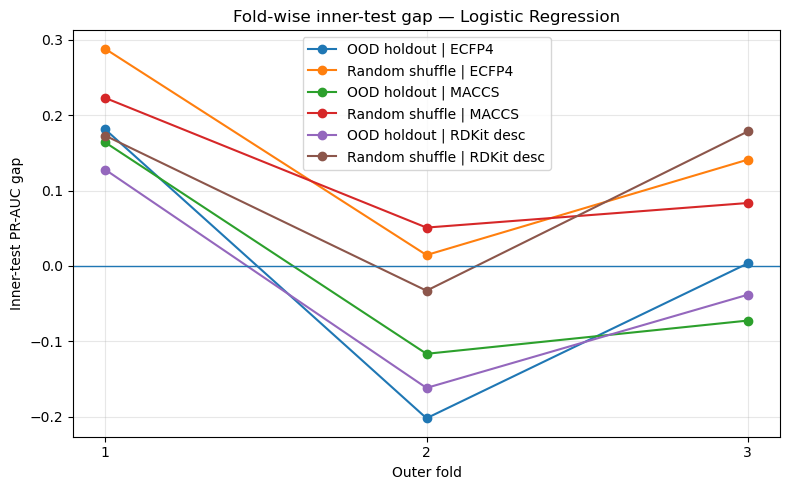

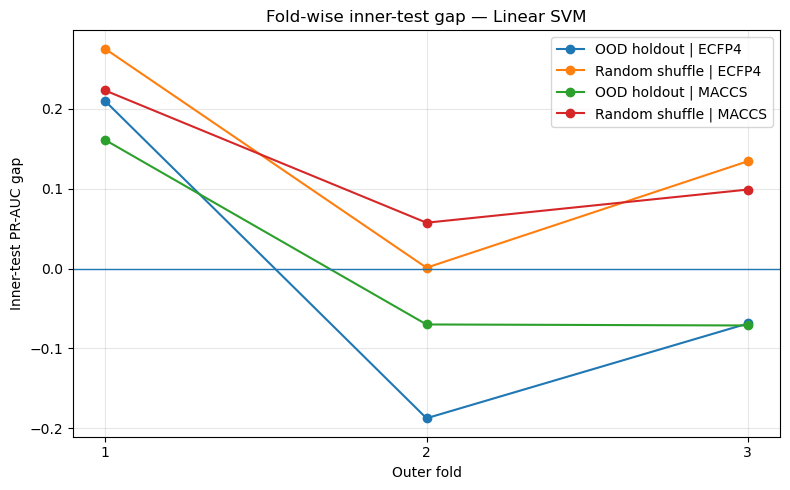

In [11]:
folds_plot = folds.copy()

folds_plot["experiment_label"] = (
    folds_plot["protocol"] + " | " + folds_plot["fingerprint"]
)

folds_plot = folds_plot.sort_values(
    ["model_order", "fingerprint_order", "protocol_order", "fold"]
)

models = folds_plot["model"].drop_duplicates().tolist()

for model in models:
    sub_model = folds_plot[folds_plot["model"] == model]

    fig, ax = plt.subplots(figsize=(8, 5))

    for label in sub_model["experiment_label"].drop_duplicates():
        sub = sub_model[sub_model["experiment_label"] == label].sort_values("fold")

        ax.plot(
            sub["fold"],
            sub["inner_test_gap"],
            marker="o",
            label=label,
        )

    ax.axhline(0, linewidth=1)
    ax.set_xticks([1, 2, 3])
    ax.set_xlabel("Outer fold")
    ax.set_ylabel("Inner-test PR-AUC gap")
    ax.set_title(f"Fold-wise inner-test gap — {model}")
    ax.legend()
    ax.grid(True, alpha=0.3)

    plt.tight_layout()

    safe_model_name = (
        model.lower()
        .replace(" ", "_")
        .replace("/", "_")
        .replace("-", "_")
    )

    plt.savefig(
        FIG_DIR / f"04_foldwise_gap_{safe_model_name}.png",
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

# Delta analysis


The delta table compares the two inner validation protocols directly.

For each model–fingerprint pair:

$$\Delta_{\text{inner}} = \text{inner}_{\text{random}} - \text{inner}_{\text{OOD}}$$

$$\Delta_{\text{test}} = \text{test}_{\text{random}} - \text{test}_{\text{OOD}}$$

$$\Delta_{\text{gap}} = \text{gap}_{\text{random}} - \text{gap}_{\text{OOD}}$$


A desirable validation protocol should not only have high inner validation score, but should also be calibrated with the final OOD test score.

In [12]:
delta.columns.tolist()

['model',
 'model_short',
 'fingerprint',
 'ood_inner_mean',
 'random_inner_mean',
 'delta_inner',
 'ood_test_mean',
 'random_test_mean',
 'delta_test',
 'ood_inner_test_gap',
 'random_inner_test_gap',
 'delta_inner_test_gap',
 'ood_train_test_gap',
 'random_train_test_gap',
 'delta_train_test_gap',
 'model_order',
 'fingerprint_order']

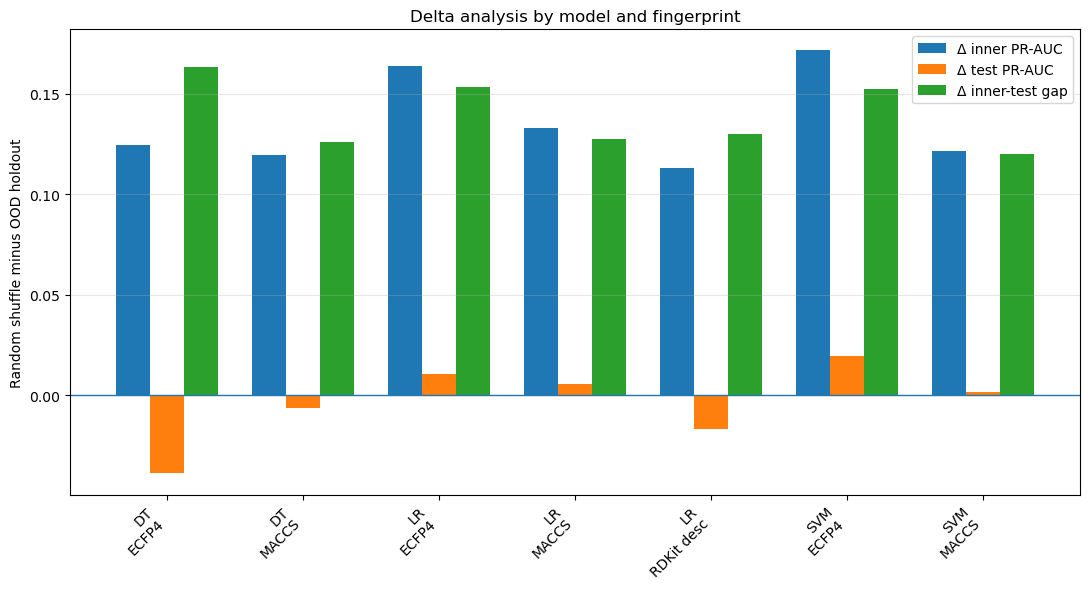

In [15]:
delta_plot = delta.copy()

delta_plot["experiment_label"] = (
    delta_plot["model_short"] + "\n" + delta_plot["fingerprint"]
)

delta_plot = delta_plot.sort_values(
    ["model_order", "fingerprint_order"]
)

metrics = [
    "delta_inner",
    "delta_test",
    "delta_inner_test_gap",
]

metric_labels = {
    "delta_inner": "Δ inner PR-AUC",
    "delta_test": "Δ test PR-AUC",
    "delta_inner_test_gap": "Δ inner-test gap",
}

labels = delta_plot["experiment_label"].drop_duplicates().tolist()
x = np.arange(len(labels))
width = 0.25

fig, ax = plt.subplots(figsize=(11, 6))

for i, metric in enumerate(metrics):
    sub = (
        delta_plot
        .set_index("experiment_label")
        .reindex(labels)
        .reset_index()
    )

    ax.bar(
        x + (i - 1) * width,
        sub[metric],
        width,
        label=metric_labels[metric],
    )

ax.axhline(0, linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha="right")
ax.set_ylabel("Random shuffle minus OOD holdout")
ax.set_title("Delta analysis by model and fingerprint")
ax.legend()
ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.savefig(FIG_DIR / "05_delta_barplot.png", dpi=300, bbox_inches="tight")
plt.show()

# Delta heatmap

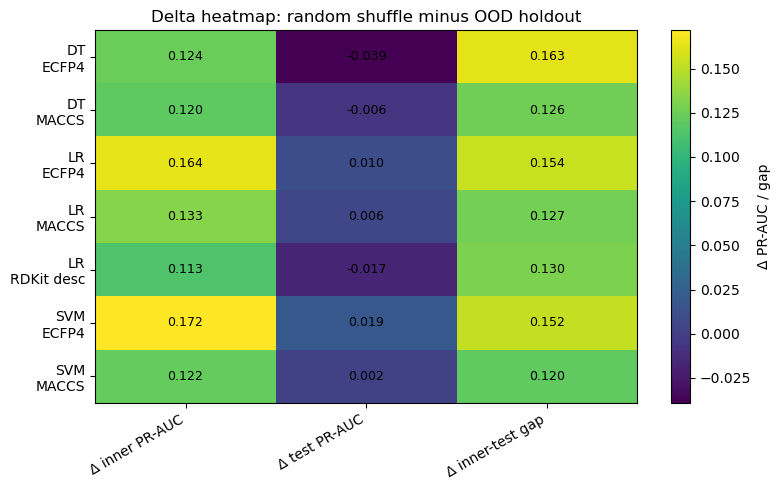

In [16]:
heatmap_df = delta_plot.set_index("experiment_label")[metrics]

fig, ax = plt.subplots(figsize=(8, 5))

im = ax.imshow(heatmap_df.values, aspect="auto")

ax.set_xticks(np.arange(len(metrics)))
ax.set_xticklabels(
    [metric_labels[m] for m in metrics],
    rotation=30,
    ha="right",
)

ax.set_yticks(np.arange(len(heatmap_df.index)))
ax.set_yticklabels(heatmap_df.index)

for i in range(heatmap_df.shape[0]):
    for j in range(heatmap_df.shape[1]):
        value = heatmap_df.iloc[i, j]
        ax.text(
            j,
            i,
            f"{value:.3f}",
            ha="center",
            va="center",
            fontsize=9,
        )

ax.set_title("Delta heatmap: random shuffle minus OOD holdout")

cbar = plt.colorbar(im, ax=ax)
cbar.set_label("Δ PR-AUC / gap")

plt.tight_layout()
plt.savefig(FIG_DIR / "06_delta_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()